In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode())
df=df.drop(columns=['Cabin'], errors='ignore')
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'], errors='ignore')
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [8]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [9]:
X = df.drop(columns = ['Survived'])
Y = df['Survived']

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state= 42)
print(X_train.shape, X_test.shape)

(712, 7) (179, 7)


In [11]:
model = GaussianNB()
model.fit(X_train, Y_train)

GaussianNB()

In [12]:
Y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(Y_test, Y_pred))
print("\n Confusion Matrix : \n" , confusion_matrix(Y_test, Y_pred))
print("\n Classification Report :\n", classification_report(Y_test, Y_pred))

Accuracy : 0.776536312849162

 Confusion Matrix : 
 [[82 23]
 [17 57]]

 Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



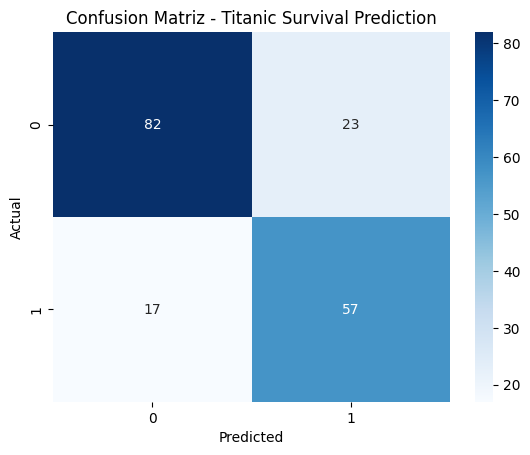

In [13]:
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matriz - Titanic Survival Prediction')
plt.show()

In [13]:
### Analysis and Findings
---Model Performance:
The Naive Bayes classifier achieved an accuracy of 77.6% on the test dataset, correctly predicting survival outcomes for 139 out of 179 passengers.

Confusion Matrix Insights:

True Negatives (82): Non-survivors correctly predicted as not surviving.
False Positives (23): Non-survivors incorrectly predicted as survivors.
False Negatives (17): Survivors incorrectly predicted as not surviving.
True Positives (57): Survivors correctly predicted as surviving.

Classification Report Insights:

For Class 0 (Did not survive): precision = 0.83, recall = 0.78, f1-score = 0.80
For Class 1 (Survived): precision = 0.71, recall = 0.77, f1-score = 0.74
The model predicts non-survivors slightly more reliably (higher precision) than survivors, likely because there were more non-survivor samples (105) than survivor samples (74) in the test set — a mild class imbalance.
The macro average (0.77 precision, 0.78 recall) and weighted average (0.78 across all metrics) confirm the model performs consistently and fairly balanced across both classes.

Key Observations:

Sex is likely one of the strongest predictors, since historical evacuation policy ("women and children first") gave female passengers a much higher survival rate.
Pclass probably plays a major role too — first-class passengers had better access to lifeboats.
Age likely contributes as well, since children were prioritized during rescue.

Limitations:
Naive Bayes assumes all features are conditionally independent, which does not fully hold here (for example, Pclass and Fare are naturally correlated). This assumption may cap the model's accuracy compared to more flexible algorithms like Random Forest or Logistic Regression, but for a simple probabilistic model, 77.6% accuracy with balanced precision/recall is a solid result.